# Disentanglement — Measuring When One Slider Controls One Factor

> **Goal:** *See* what it means for a latent space to be "disentangled", and — more
> importantly — *feel* how the three families of metrics actually measure it, and where
> each one is blind.

A representation is **disentangled** when changing a single latent coordinate changes exactly
one ground-truth factor of variation (shape, size, color, position, ...) and leaves the others
untouched. The hard part is not the definition — it is *quantifying* how close a real model
gets. This notebook builds a tiny generative world with known factors, two encoders (one clean,
one entangled), and then re-derives each metric family from scratch on top of them.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **The MI matrix** | What does "disentangled" vs "entangled" look like as a picture? |
| 2 | **Mutual Information Gap (MIG)** | How does the *gap* between the top-2 latents quantify "one factor, one dimension"? |
| 3 | **DCI importance matrix** | How do a predictor's importances turn into Disentanglement & Completeness scores? |
| 4 | **DCI's blind spot** | Why can a *powerful* predictor report a high score on an entangled latent? |
| 5 | **Intervention metric (FactorVAE)** | How does *fixing a factor* reveal which dimension encodes it? |
| 6 | **MIG vs correlated factors (DMIG)** | Why does MIG punish a perfect encoder when factors are correlated — and how does DMIG fix it? |

---
**Linked theory:** [research/02-disentanglement.md](../research/02-disentanglement.md)  ·  **Chạy:** `uv run jupyter lab` từ thư mục `latent-anything-theory/` (cần các package trong `pyproject.toml`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import mutual_info_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete. NumPy:', np.__version__)

Setup complete. NumPy: 2.4.6


---
## A shared generative world: known factors, two encoders

Every experiment below uses the same setup, so the metrics are comparable.

- **Ground-truth factors** $f \in [0,1]^4$: `shape`, `size`, `color`, `position`. They are the
  *causes* — the things we wish each latent dimension would isolate.
- **Disentangled encoder** $z = E_\text{good}(f)$: each latent dimension is a (permuted, scaled,
  slightly noisy) copy of *one* factor. This is the ideal a real model only approximates.
- **Entangled encoder** $z = E_\text{bad}(f)$: the same factors passed through a random
  rotation, so every latent dimension is a blend of *all* factors.

A disentangled representation is allowed to **permute** and **rescale** factors — what it must not
do is **mix** them. The rotation is exactly the forbidden operation, which makes it the perfect
foil.

In [2]:
np.random.seed(0)

FACTOR_NAMES = ['shape', 'size', 'color', 'position']
LATENT_NAMES = ['z0', 'z1', 'z2', 'z3']
K = len(FACTOR_NAMES)         # number of ground-truth factors
N = 6000                      # samples


def sample_factors(n, rng):
    """Independent factors, each uniform on [0, 1]."""
    return rng.random((n, K))


# A disentangled encoder: permute + scale + tiny noise. One factor -> one dimension.
PERM = np.array([2, 0, 3, 1])           # z0<-color, z1<-shape, z2<-position, z3<-size
SCALE = np.array([1.0, 1.4, 0.7, 1.1])


def encode_good(F, noise=0.02, rng=None):
    rng = rng or np.random.default_rng(0)
    z = F[:, PERM] * SCALE
    return z + noise * rng.standard_normal(z.shape)


# An entangled encoder: rotate the factors so every dim mixes all of them.
_R = np.linalg.qr(np.random.default_rng(7).standard_normal((K, K)))[0]


def encode_bad(F, noise=0.02, rng=None):
    rng = rng or np.random.default_rng(0)
    z = (F - 0.5) @ _R
    return z + noise * rng.standard_normal(z.shape)


rng = np.random.default_rng(0)
F = sample_factors(N, rng)
Z_good = encode_good(F, rng=rng)
Z_bad = encode_bad(F, rng=rng)

print('factors F  :', F.shape)
print('Z_good     :', Z_good.shape, '(disentangled encoder)')
print('Z_bad      :', Z_bad.shape, '(entangled encoder)')
print('rotation used by the entangled encoder:')
print(np.round(_R, 2))

factors F  : (6000, 4)
Z_good     : (6000, 4) (disentangled encoder)
Z_bad      : (6000, 4) (entangled encoder)
rotation used by the entangled encoder:
[[-0.    0.25 -0.67  0.7 ]
 [ 0.67 -0.29 -0.54 -0.42]
 [ 0.73  0.07  0.5   0.46]
 [-0.16 -0.92  0.03  0.36]]


### What you see

We now have one set of ground-truth factors and two views of it. `Z_good` is just the factors
shuffled and stretched — recoverable one-for-one. `Z_bad` runs them through the printed rotation
matrix, whose rows have **several non-trivial entries**: every output dimension is a weighted sum
of all four factors. Keep this contrast in mind — every metric below is, in the end, just a
different way of detecting that rotation.

---
## Experiment 1: The Mutual-Information matrix — disentanglement as a picture

**Question:** Before any single number, what does disentanglement *look like*? If we measure the
**mutual information** $I(z_i; f_j)$ between every latent dimension and every factor, a
disentangled space should give a matrix with **one bright cell per row and per column** — a
permuted diagonal. An entangled space should give a dense, smeared matrix.

Mutual information measures how much knowing one variable reduces uncertainty about the other; it
is the natural currency for "how much does this dimension know about that factor".

In [3]:
np.random.seed(1)


def entropy_hist(x, bins=24):
    """Differential-ish entropy of a 1D sample via histogram binning (nats)."""
    counts = np.histogram(x, bins=bins)[0]
    p = counts / counts.sum()
    p = p[p > 0]
    return -np.sum(p * np.log(p))


def mi_hist(x, y, bins=24):
    """Mutual information of two continuous samples via a 2D histogram (nats)."""
    c_xy = np.histogram2d(x, y, bins=bins)[0]
    return mutual_info_score(None, None, contingency=c_xy)


def mi_matrix(Z, F, bins=24):
    D, K = Z.shape[1], F.shape[1]
    M = np.zeros((D, K))
    for i in range(D):
        for j in range(K):
            M[i, j] = mi_hist(Z[:, i], F[:, j], bins)
    return M


M_good = mi_matrix(Z_good, F)
M_bad = mi_matrix(Z_bad, F)
print('MI matrix (good): each row/col has one clear winner')
print(np.round(M_good, 2))
print('\nMI matrix (bad): smeared across dimensions')
print(np.round(M_bad, 2))

MI matrix (good): each row/col has one clear winner
[[0.04 0.04 2.24 0.05]
 [2.4  0.05 0.05 0.05]
 [0.05 0.05 0.05 2.04]
 [0.05 2.3  0.04 0.04]]

MI matrix (bad): smeared across dimensions
[[0.05 0.37 0.44 0.06]
 [0.1  0.11 0.05 0.9 ]
 [0.33 0.22 0.21 0.04]
 [0.37 0.15 0.16 0.11]]


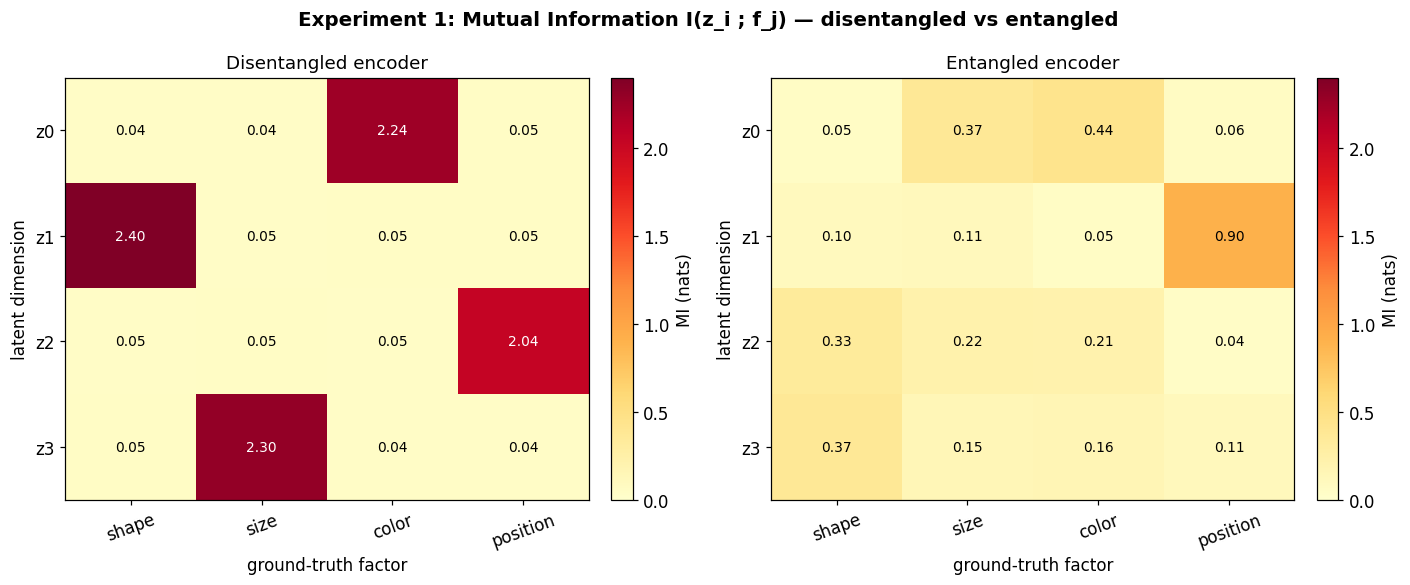

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
fig.suptitle('Experiment 1: Mutual Information I(z_i ; f_j) — disentangled vs entangled',
             fontsize=13, fontweight='bold')

vmax = max(M_good.max(), M_bad.max())
for ax, M, name in [(axes[0], M_good, 'Disentangled encoder'),
                    (axes[1], M_bad, 'Entangled encoder')]:
    im = ax.imshow(M, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(K)); ax.set_xticklabels(FACTOR_NAMES, rotation=20)
    ax.set_yticks(range(K)); ax.set_yticklabels(LATENT_NAMES)
    ax.set_xlabel('ground-truth factor')
    ax.set_ylabel('latent dimension')
    ax.set_title(name)
    ax.grid(False)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center',
                    color='black' if M[i, j] < 0.55 * vmax else 'white', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='MI (nats)')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The disentangled encoder (left) produces a clean **permuted diagonal**
   — `z1` lights up only for `shape`, `z0` only for `color`, and so on; every other cell is near
   zero. The entangled encoder (right) is a **dense block**: every latent dimension carries
   substantial information about every factor.

2. **Why it looks this way:** `Z_good` is a one-to-one relabelling of the factors, so each
   dimension's uncertainty is resolved by exactly one factor — MI concentrates in a single cell per
   row. The rotation inside `Z_bad` spreads each factor's signal across all output axes, so the
   information is shared everywhere and no single cell dominates.

3. **Key takeaway:** Disentanglement has a visual signature — a sparse, one-winner-per-row-and-column
   MI matrix. Every numeric metric that follows is a way of compressing this picture into a score:
   MIG looks at the *gap* within each column, DCI looks at the *concentration* within rows and
   columns.

---
## Experiment 2: Mutual Information Gap (MIG) — the distance between top-1 and top-2

**Question:** For a given factor, how do we score "one dimension owns it"? MIG's answer: look at
the two latent dimensions that know the most about that factor, and measure the **gap** between
them, normalized by the factor's entropy:

$$\text{MIG}_j = \frac{I(z_{(1)}; f_j) - I(z_{(2)}; f_j)}{H(f_j)}, \qquad
\text{MIG} = \frac{1}{K}\sum_j \text{MIG}_j$$

A big gap means the information is *concentrated* in one dimension (top-1 ≫ top-2). A small gap
means the factor's information **leaked (spillover)** across several dimensions.

In [5]:
np.random.seed(2)


def compute_mig(M, F, bins=24):
    """MIG from a precomputed MI matrix M (D x K) and factors F."""
    K = F.shape[1]
    Hf = np.array([entropy_hist(F[:, j], bins) for j in range(K)])
    per_factor = np.zeros(K)
    for j in range(K):
        col = np.sort(M[:, j])[::-1]      # descending MI over latent dims
        per_factor[j] = (col[0] - col[1]) / Hf[j]
    return per_factor, Hf


mig_good_pf, Hf = compute_mig(M_good, F)
mig_bad_pf, _ = compute_mig(M_bad, F)
print(f'Factor entropies H(f_j): {np.round(Hf, 3)}')
print(f'\nMIG good : per-factor {np.round(mig_good_pf, 3)}  ->  mean = {mig_good_pf.mean():.3f}')
print(f'MIG bad  : per-factor {np.round(mig_bad_pf, 3)}  ->  mean = {mig_bad_pf.mean():.3f}')

Factor entropies H(f_j): [3.176 3.174 3.176 3.177]

MIG good : per-factor [0.74  0.71  0.691 0.625]  ->  mean = 0.692
MIG bad  : per-factor [0.01  0.046 0.073 0.251]  ->  mean = 0.095


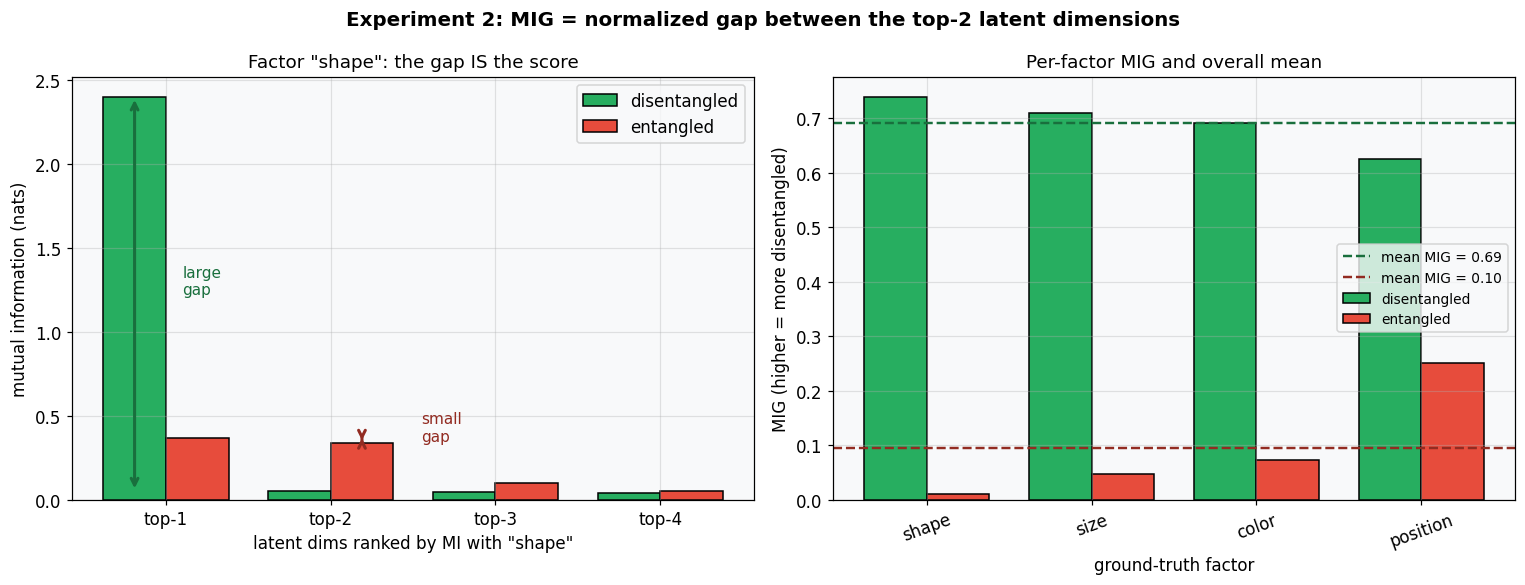

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
fig.suptitle('Experiment 2: MIG = normalized gap between the top-2 latent dimensions',
             fontsize=13, fontweight='bold')

# --- Left: sorted MI per latent for ONE factor, showing the gap ---
ax1 = axes[0]
factor_j = 0  # 'shape'
g_sorted = np.sort(M_good[:, factor_j])[::-1]
b_sorted = np.sort(M_bad[:, factor_j])[::-1]
x = np.arange(K)
w = 0.38
ax1.bar(x - w / 2, g_sorted, w, color='#27ae60', edgecolor='black', label='disentangled')
ax1.bar(x + w / 2, b_sorted, w, color='#e74c3c', edgecolor='black', label='entangled')
ax1.annotate('', xy=(-w / 2, g_sorted[0]), xytext=(-w / 2, g_sorted[1]),
             arrowprops=dict(arrowstyle='<->', color='#196f3d', lw=2))
ax1.text(0.10, (g_sorted[0] + g_sorted[1]) / 2, 'large\ngap', color='#196f3d', fontsize=10)
ax1.annotate('', xy=(1 - w / 2 + w, b_sorted[0]), xytext=(1 - w / 2 + w, b_sorted[1]),
             arrowprops=dict(arrowstyle='<->', color='#922b21', lw=2))
ax1.text(1.55, (b_sorted[0] + b_sorted[1]) / 2, 'small\ngap', color='#922b21', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(['top-1', 'top-2', 'top-3', 'top-4'])
ax1.set_xlabel(f'latent dims ranked by MI with "{FACTOR_NAMES[factor_j]}"')
ax1.set_ylabel('mutual information (nats)')
ax1.set_title(f'Factor "{FACTOR_NAMES[factor_j]}": the gap IS the score')
ax1.legend()

# --- Right: per-factor MIG and the mean ---
ax2 = axes[1]
x = np.arange(K)
ax2.bar(x - w / 2, mig_good_pf, w, color='#27ae60', edgecolor='black', label='disentangled')
ax2.bar(x + w / 2, mig_bad_pf, w, color='#e74c3c', edgecolor='black', label='entangled')
ax2.axhline(mig_good_pf.mean(), color='#196f3d', ls='--', lw=1.6,
            label=f'mean MIG = {mig_good_pf.mean():.2f}')
ax2.axhline(mig_bad_pf.mean(), color='#922b21', ls='--', lw=1.6,
            label=f'mean MIG = {mig_bad_pf.mean():.2f}')
ax2.set_xticks(x); ax2.set_xticklabels(FACTOR_NAMES, rotation=20)
ax2.set_xlabel('ground-truth factor')
ax2.set_ylabel('MIG (higher = more disentangled)')
ax2.set_title('Per-factor MIG and overall mean')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** On the left, for the factor `shape`, the disentangled encoder has a tall
   top-1 bar and a near-zero top-2 bar — a **large gap**. The entangled encoder's top-1 and top-2
   are almost the same height — a **tiny gap**. On the right, this holds for every factor, so the
   mean MIG is high for the disentangled space and near zero for the entangled one.

2. **Why it looks this way:** MIG asks a sharp question — *"is the information in one dimension, or
   shared?"* When a factor owns a single axis, top-1 captures (almost) all of $I(z;f)$ and top-2 is
   left with crumbs. When the rotation spreads a factor over several axes, two or more dimensions
   each grab a similar slice, so top-1 ≈ top-2 and the gap collapses.

3. **Key takeaway:** MIG turns "one factor, one dimension" into the distance between the two
   best-informed dimensions, normalized by $H(f_j)$ so factors with different entropies are
   comparable. It needs no trained predictor — but it implicitly **assumes the factors are
   independent**, an assumption Experiment 6 deliberately breaks.

---
## Experiment 3: DCI — turning a predictor's importances into D and C

**Question:** Instead of information theory, what if we *train a predictor* to recover each factor
from the latents, and read off **how much it relied on each dimension**? Stacking those importances
gives a matrix $R$ where $R_{ij}$ = importance of latent $i$ for factor $j$. DCI reads two
complementary scores off it:

- **Disentanglement (D)** — *per latent (row)*: does dimension $i$ matter for only **one** factor?
  $D_i = 1 - H_{\text{row}}(P_i)$ with $P_{ij} = R_{ij} / \sum_k R_{ik}$.
- **Completeness (C)** — *per factor (column)*: is factor $j$ captured by only **one** dimension?
  $C_j = 1 - H_{\text{col}}(P_j)$ with $P_{ij} = R_{ij} / \sum_k R_{kj}$.

Low entropy of a row/column → the importance is concentrated → high score.

In [7]:
np.random.seed(3)


def importance_matrix(Z, F, n_estimators=60):
    """R[i, j] = importance of latent dim i when predicting factor j (random forest)."""
    D, K = Z.shape[1], F.shape[1]
    R = np.zeros((D, K))
    info = np.zeros(K)
    for j in range(K):
        rf = RandomForestRegressor(n_estimators=n_estimators, random_state=0, n_jobs=-1)
        rf.fit(Z, F[:, j])
        R[:, j] = rf.feature_importances_
        info[j] = max(rf.score(Z, F[:, j]), 0.0)   # informativeness (R^2)
    return R, info


def _norm_entropy(p, base_n):
    p = p[p > 0]
    return -np.sum(p * np.log(p)) / np.log(base_n)


def dci_scores(R):
    D, K = R.shape
    # Disentanglement: entropy across factors, per latent (row)
    P_rows = R / (R.sum(axis=1, keepdims=True) + 1e-12)
    D_i = np.array([1 - _norm_entropy(P_rows[i], K) for i in range(D)])
    rho = R.sum(axis=1) / R.sum()
    disent = float(np.sum(rho * D_i))
    # Completeness: entropy across latents, per factor (column)
    P_cols = R / (R.sum(axis=0, keepdims=True) + 1e-12)
    C_j = np.array([1 - _norm_entropy(P_cols[:, j], D) for j in range(K)])
    complete = float(C_j.mean())
    return disent, complete, D_i, C_j


R_good, info_good = importance_matrix(Z_good, F)
R_bad, info_bad = importance_matrix(Z_bad, F)
D_good, C_good, Di_g, Cj_g = dci_scores(R_good)
D_bad, C_bad, Di_b, Cj_b = dci_scores(R_bad)

print('DCI scores            Disentanglement   Completeness   Informativeness(meanR^2)')
print(f'  disentangled enc.        {D_good:.3f}            {C_good:.3f}          {info_good.mean():.3f}')
print(f'  entangled    enc.        {D_bad:.3f}            {C_bad:.3f}          {info_bad.mean():.3f}')

DCI scores            Disentanglement   Completeness   Informativeness(meanR^2)
  disentangled enc.        0.980            0.980          0.999
  entangled    enc.        0.363            0.363          0.998


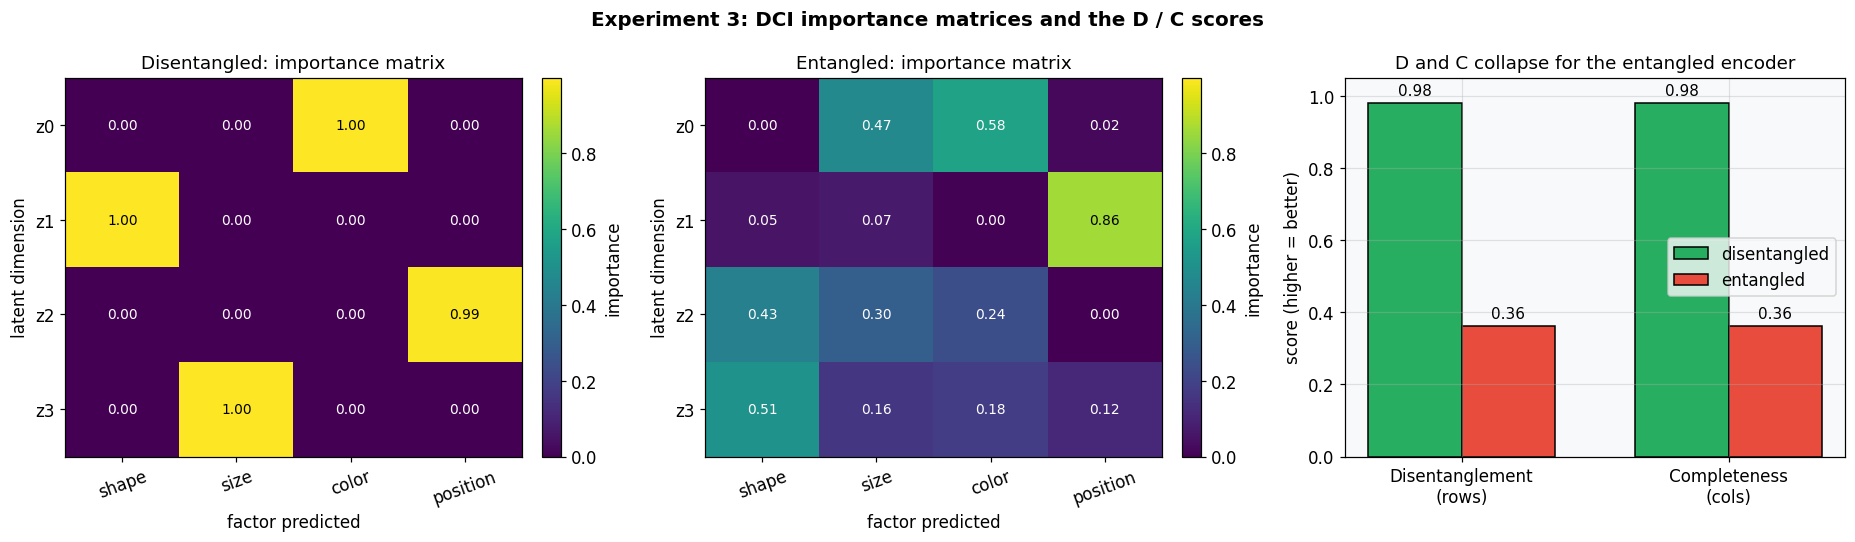

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Experiment 3: DCI importance matrices and the D / C scores',
             fontsize=13, fontweight='bold')

vmax = max(R_good.max(), R_bad.max())
for ax, R, name in [(axes[0], R_good, 'Disentangled: importance matrix'),
                    (axes[1], R_bad, 'Entangled: importance matrix')]:
    im = ax.imshow(R, cmap='viridis', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(K)); ax.set_xticklabels(FACTOR_NAMES, rotation=20)
    ax.set_yticks(range(K)); ax.set_yticklabels(LATENT_NAMES)
    ax.set_xlabel('factor predicted'); ax.set_ylabel('latent dimension')
    ax.set_title(name); ax.grid(False)
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            ax.text(j, i, f'{R[i, j]:.2f}', ha='center', va='center',
                    color='white' if R[i, j] < 0.6 * vmax else 'black', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='importance')

# --- Right: the two scalar scores ---
ax3 = axes[2]
x = np.arange(2)
w = 0.35
ax3.bar(x - w / 2, [D_good, C_good], w, color='#27ae60', edgecolor='black',
        label='disentangled')
ax3.bar(x + w / 2, [D_bad, C_bad], w, color='#e74c3c', edgecolor='black',
        label='entangled')
for xi, (vg, vb) in zip(x, [(D_good, D_bad), (C_good, C_bad)]):
    ax3.text(xi - w / 2, vg + 0.02, f'{vg:.2f}', ha='center', fontsize=10)
    ax3.text(xi + w / 2, vb + 0.02, f'{vb:.2f}', ha='center', fontsize=10)
ax3.set_xticks(x); ax3.set_xticklabels(['Disentanglement\n(rows)', 'Completeness\n(cols)'])
ax3.set_ylabel('score (higher = better)')
ax3.set_ylim(0, 1.05)
ax3.set_title('D and C collapse for the entangled encoder')
ax3.legend()

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The disentangled importance matrix (left) is again a permuted diagonal —
   each forest leans on exactly one latent dimension. The entangled matrix (middle) spreads
   importance across the whole column. The bars (right) turn this into numbers: D and C are near 1
   for the clean encoder and drop sharply for the entangled one.

2. **Why it looks this way:** With `Z_good`, a single dimension is a near-perfect linear stand-in for
   a factor, so the forest's importance piles onto it — low row/column entropy, high D and C. With
   `Z_bad`, the forest must combine several rotated dimensions to recover any factor, so importance
   is shared — high entropy, low D and C. Note D and C are *different*: D fails if one dimension
   serves many factors, C fails if one factor needs many dimensions.

3. **Key takeaway:** DCI reframes disentanglement as **concentration of predictive importance**, and
   usefully splits it into two directions (compactness per dimension vs per factor). But it inherits
   the predictor's behaviour — which is exactly the crack Experiment 4 pries open.

---
## Experiment 4: DCI's blind spot — a strong predictor can hide entanglement

**Question:** DCI's Informativeness term is just "how well can the predictor recover the factors?"
But a sufficiently powerful, **nonlinear** predictor can untangle a mess that a linear probe cannot.
So can a model look "informative" (high $R^2$) even when its latent space is *not* geometrically
disentangled? If so, reading Informativeness as evidence of disentanglement is a trap.

We build a deliberately **scrambled** latent — the factors rotated together and then pushed through a
strong, *invertible* nonlinearity ($\sinh$) — and compare what a *linear* probe sees versus what a
*random forest* sees. Because the map is invertible, the factors are genuinely still in there; only
the *shape* of the relationship changes.

In [9]:
np.random.seed(4)

# A fully-entangled latent: rotate all factors together, then apply a strong invertible
# nonlinearity elementwise. Invertible => the factors ARE recoverable (by a strong predictor),
# but the factor->latent relationship is far from linear.
y = (F - 0.5) @ _R
y = y / y.std(axis=0)
Z_scrambled = np.sinh(4.0 * y)
Z_scrambled += 0.02 * np.random.standard_normal(Z_scrambled.shape)

# Informativeness under a WEAK (linear) vs STRONG (forest) predictor.
n_tr = 4000
lin_r2, rf_r2 = np.zeros(K), np.zeros(K)
for j in range(K):
    y = F[:, j]
    lin = LinearRegression().fit(Z_scrambled[:n_tr], y[:n_tr])
    rf = RandomForestRegressor(n_estimators=80, random_state=0, n_jobs=-1).fit(
        Z_scrambled[:n_tr], y[:n_tr])
    lin_r2[j] = max(r2_score(y[n_tr:], lin.predict(Z_scrambled[n_tr:])), 0)
    rf_r2[j] = max(r2_score(y[n_tr:], rf.predict(Z_scrambled[n_tr:])), 0)

# DCI-Disentanglement of the scrambled latent (uses the forest importances).
R_scr, _ = importance_matrix(Z_scrambled, F)
D_scr, C_scr, _, _ = dci_scores(R_scr)

print('Scrambled (entangled) latent — Informativeness R^2 per factor:')
print(f'  linear probe : {np.round(lin_r2, 2)}  (mean {lin_r2.mean():.2f})')
print(f'  random forest: {np.round(rf_r2, 2)}  (mean {rf_r2.mean():.2f})')
print(f'\nYet DCI-Disentanglement of this latent is only D = {D_scr:.2f}, C = {C_scr:.2f}')

Scrambled (entangled) latent — Informativeness R^2 per factor:
  linear probe : [0.13 0.22 0.18 0.2 ]  (mean 0.18)
  random forest: [1.   0.99 0.99 1.  ]  (mean 0.99)

Yet DCI-Disentanglement of this latent is only D = 0.37, C = 0.37


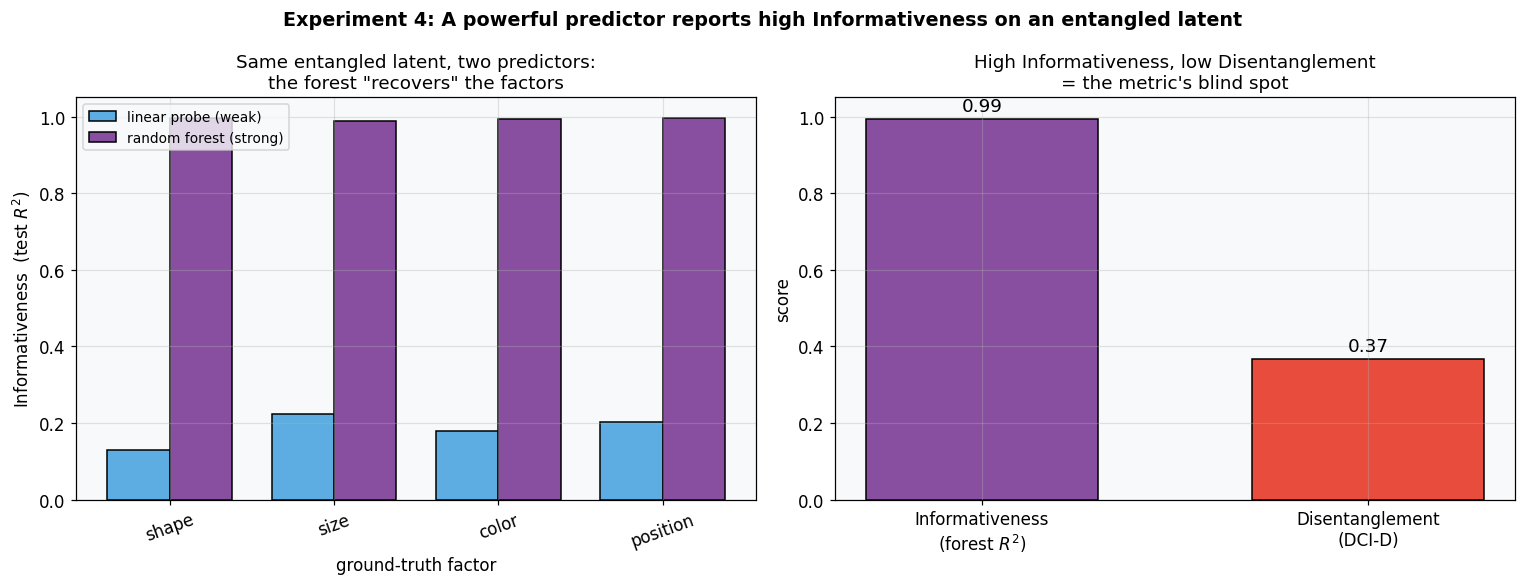

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
fig.suptitle('Experiment 4: A powerful predictor reports high Informativeness on an '
             'entangled latent', fontsize=12.5, fontweight='bold')

# --- Left: informativeness, weak vs strong predictor ---
ax1 = axes[0]
x = np.arange(K)
w = 0.38
ax1.bar(x - w / 2, lin_r2, w, color='#5dade2', edgecolor='black', label='linear probe (weak)')
ax1.bar(x + w / 2, rf_r2, w, color='#884ea0', edgecolor='black', label='random forest (strong)')
ax1.set_xticks(x); ax1.set_xticklabels(FACTOR_NAMES, rotation=20)
ax1.set_ylabel('Informativeness  (test $R^2$)')
ax1.set_ylim(0, 1.05)
ax1.set_xlabel('ground-truth factor')
ax1.set_title('Same entangled latent, two predictors:\nthe forest "recovers" the factors')
ax1.legend(fontsize=9)

# --- Right: the contradiction — high I, low D ---
ax2 = axes[1]
labels = ['Informativeness\n(forest $R^2$)', 'Disentanglement\n(DCI-D)']
vals = [rf_r2.mean(), D_scr]
colors = ['#884ea0', '#e74c3c']
bars = ax2.bar(labels, vals, color=colors, edgecolor='black', width=0.6)
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 0.02, f'{v:.2f}', ha='center', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('score')
ax2.set_title('High Informativeness, low Disentanglement\n= the metric\'s blind spot')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** On the scrambled, fully-entangled latent, the **linear probe** recovers
   the factors poorly (low $R^2$, left blue bars), but the **random forest** recovers them well (tall
   purple bars). On the right, that same forest yields high mean Informativeness while the DCI
   Disentanglement score stays low — the two scores disagree.

2. **Why it looks this way:** The factors are still *present* in the scrambled latent — the rotation
   and $\sinh$ are invertible, so no information was lost. A flexible nonlinear predictor can undo that
   warping and read the factors back out (high $R^2$), while the linear probe cannot fit the curved
   $\sinh^{-1}$ relationship. But "the factors are *recoverable*" is
   a much weaker property than "the factors live on *separate axes*", which is what D measures and
   what stays low.

3. **Key takeaway:** This is precisely the research file's warning: **DCI is hostage to the predictor
   you choose.** A clever classifier can make an entangled space look good on Informativeness, and can
   even smear importances in ways that flatter D. Always report which predictor was used, and never
   read "the factors are decodable" as "the space is disentangled".

---
## Experiment 5: The intervention metric (FactorVAE) — fix a factor, watch the variance drop

**Question:** The causal/intervention family asks a different question: if we **hold one factor
fixed** and let all the others vary randomly, which latent dimension *stops moving*? That dimension
must be the one encoding the fixed factor. This is the idea behind the FactorVAE / $\beta$-VAE
metrics.

Procedure: normalize each latent dimension by its global standard deviation; build many batches in
each of which one factor is pinned; the dimension with the **smallest empirical variance** in a
batch votes for the pinned factor. A clean majority-vote table means disentanglement.

In [11]:
np.random.seed(5)


def factorvae_votes(encode, n_batches=600, batch_size=256, seed=5):
    rng = np.random.default_rng(seed)
    # Global scale of each latent dim, estimated from a large random sample.
    s = encode(sample_factors(5000, rng), rng=rng).std(axis=0)
    votes = np.zeros((K, K))      # votes[dim, fixed_factor]
    for _ in range(n_batches):
        j = rng.integers(K)                      # factor to pin
        Fb = sample_factors(batch_size, rng)
        Fb[:, j] = rng.random()                  # pin factor j to a constant
        Zb = encode(Fb, rng=rng) / s
        d = int(np.argmin(Zb.var(axis=0)))       # least-varying dim wins
        votes[d, j] += 1
    accuracy = votes.max(axis=0).sum() / votes.sum()   # majority-vote classifier
    return votes, accuracy


votes_good, acc_good = factorvae_votes(encode_good)
votes_bad, acc_bad = factorvae_votes(encode_bad)
print(f'FactorVAE-style accuracy   disentangled: {acc_good:.3f}   entangled: {acc_bad:.3f}')
print('\nVote table (good) rows=dim, cols=fixed factor:')
print(votes_good.astype(int))
print('\nVote table (bad):')
print(votes_bad.astype(int))

FactorVAE-style accuracy   disentangled: 1.000   entangled: 0.933

Vote table (good) rows=dim, cols=fixed factor:
[[  0   0 155   0]
 [148   0   0   0]
 [  0   0   0 148]
 [  0 149   0   0]]

Vote table (bad):
[[  0 149 155   0]
 [  0   0   0 148]
 [ 40   0   0   0]
 [108   0   0   0]]


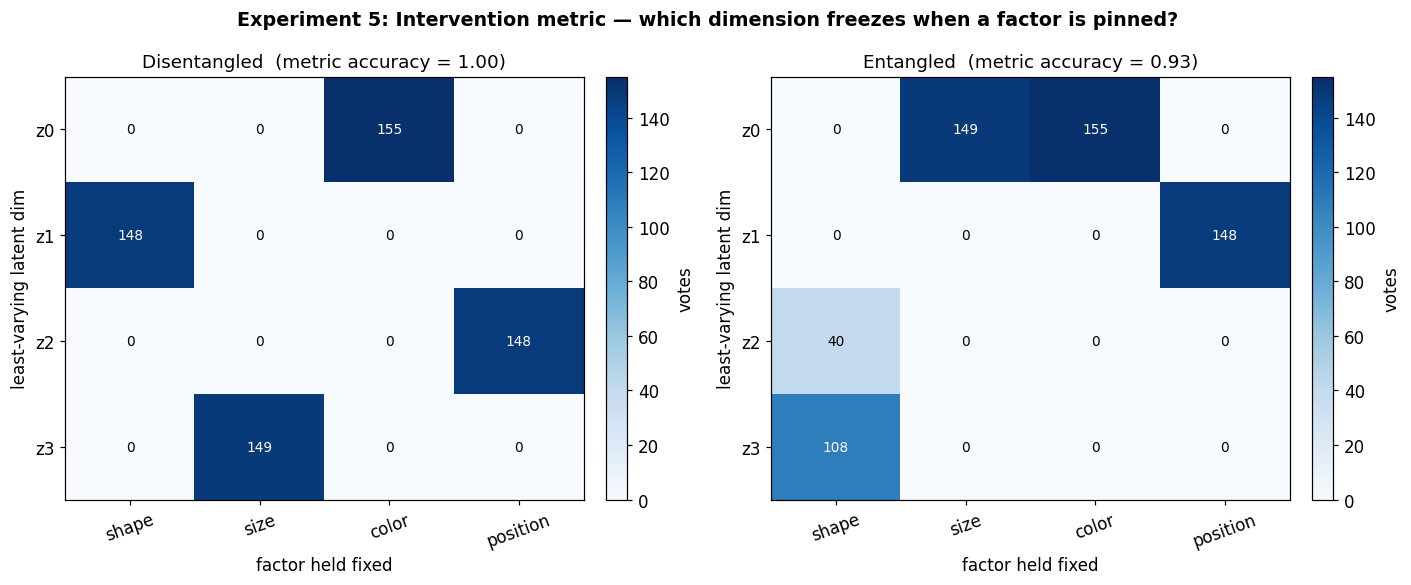

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))
fig.suptitle('Experiment 5: Intervention metric — which dimension freezes when a factor is pinned?',
             fontsize=12.5, fontweight='bold')

vmax = max(votes_good.max(), votes_bad.max())
for ax, V, name, acc in [(axes[0], votes_good, 'Disentangled', acc_good),
                         (axes[1], votes_bad, 'Entangled', acc_bad)]:
    im = ax.imshow(V, cmap='Blues', vmin=0, vmax=vmax, aspect='auto')
    ax.set_xticks(range(K)); ax.set_xticklabels(FACTOR_NAMES, rotation=20)
    ax.set_yticks(range(K)); ax.set_yticklabels(LATENT_NAMES)
    ax.set_xlabel('factor held fixed'); ax.set_ylabel('least-varying latent dim')
    ax.set_title(f'{name}  (metric accuracy = {acc:.2f})'); ax.grid(False)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, int(V[i, j]), ha='center', va='center',
                    color='black' if V[i, j] < 0.6 * vmax else 'white', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='votes')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** For the disentangled encoder (left), the vote table is a clean permuted
   diagonal — pinning `shape` almost always freezes the same single dimension, pinning `color` freezes
   another, and so on, giving near-perfect metric accuracy. For the entangled encoder (right), the
   votes scatter across rows and the accuracy collapses.

2. **Why it looks this way:** When a factor owns one axis, fixing that factor removes essentially all
   the variance from that one axis while the others keep moving — so `argmin variance` reliably points
   to it. Under the rotation, pinning one factor reduces variance a *little* on every axis at once, so
   the least-varying dimension is essentially random from batch to batch.

3. **Key takeaway:** The intervention metric is **causal in spirit** — it manipulates the generative
   process and watches the latent respond, rather than passively measuring correlations. The
   normalization by global std is essential (otherwise the smallest-scale dimension always wins). This
   is the same machinery behind advanced UC / CG counterfactual scores: intervene, then check the
   effect is isolated.

---
## Experiment 6: MIG vs correlated factors — why a perfect encoder fails, and how DMIG fixes it

**Question:** MIG silently assumes the factors are independent. What happens to a **perfectly
disentangled** encoder when two real-world factors are correlated (color and shape often co-occur)?
And does the **dependency-aware** variant DMIG repair the damage?

When `shape` and `color` are correlated, the dimension that owns `shape` *also* shares information
with `color` (through the correlation). So for the factor `color`, top-1 and top-2 both look
informative — the gap shrinks — even though each dimension cleanly owns its own factor. DMIG keeps the
same $H(f_j)$ normalizer but replaces the **second term of the gap** with a *conditional* mutual
information $I(z_{(2)}; f_j \mid f_{(2)})$ — the information the second dimension has about $f_j$
*beyond* what the factor it actually owns ($f_{(2)}$) already explains. For a clean encoder that
surplus is ~0, so the gap (and the score) barely moves.

In [13]:
np.random.seed(6)


def sample_correlated(n, rho, rng):
    """Factors where 'shape'(0) and 'color'(2) are correlated with strength rho."""
    Fa = rng.random((n, K))
    Fa[:, 2] = rho * Fa[:, 0] + (1 - rho) * Fa[:, 2]   # color leaks toward shape
    return Fa


def cond_mi(z, f, c, bins=12, cbins=6):
    """I(z; f | c): average MI(z; f) inside bins of the conditioning factor c."""
    edges = np.histogram_bin_edges(c, bins=cbins)
    idx = np.clip(np.digitize(c, edges[1:-1]), 0, cbins - 1)
    val = 0.0
    for b in range(cbins):
        m = idx == b
        if m.sum() > 50:
            val += m.mean() * mi_hist(z[m], f[m], bins=bins)
    return val


rhos = np.linspace(0.0, 0.95, 9)
mig_curve, dmig_curve = [], []
for rho in rhos:
    rng_r = np.random.default_rng(int(rho * 1000) + 1)
    Fr = sample_correlated(N, rho, rng_r)
    Zr = encode_good(Fr, rng=rng_r)                 # the SAME perfect encoder
    Mr = mi_matrix(Zr, Fr)
    mig_j, dmig_j = [], []
    for j in range(K):
        order = np.argsort(Mr[:, j])[::-1]
        top1, top2 = order[0], order[1]
        Hf = entropy_hist(Fr[:, j])
        # MIG: normalized gap between the two best-informed dimensions.
        mig_j.append((Mr[top1, j] - Mr[top2, j]) / Hf)
        # DMIG: the 2nd dim only looks informative about f_j because f_j correlates with the
        # factor that dim actually owns. Replace I(z_top2; f_j) with the conditional MI
        # I(z_top2; f_j | f_owner) -- the information beyond what the correlation explains
        # (~0 for a clean encoder), so the gap stops sagging.
        f_owner = int(np.argmax(Mr[top2, :]))
        leak = cond_mi(Zr[:, top2], Fr[:, j], Fr[:, f_owner])
        dmig_j.append((Mr[top1, j] - leak) / Hf)
    mig_curve.append(np.mean(mig_j))
    dmig_curve.append(np.mean(dmig_j))

mig_curve, dmig_curve = np.array(mig_curve), np.array(dmig_curve)
print('correlation rho   :', np.round(rhos, 2))
print('MIG  (marginal)   :', np.round(mig_curve, 3))
print('DMIG (conditional):', np.round(dmig_curve, 3))

correlation rho   : [0.   0.12 0.24 0.36 0.48 0.59 0.71 0.83 0.95]
MIG  (marginal)   : [0.694 0.684 0.67  0.651 0.624 0.59  0.535 0.462 0.362]
DMIG (conditional): [0.689 0.682 0.68  0.679 0.674 0.672 0.662 0.644 0.577]


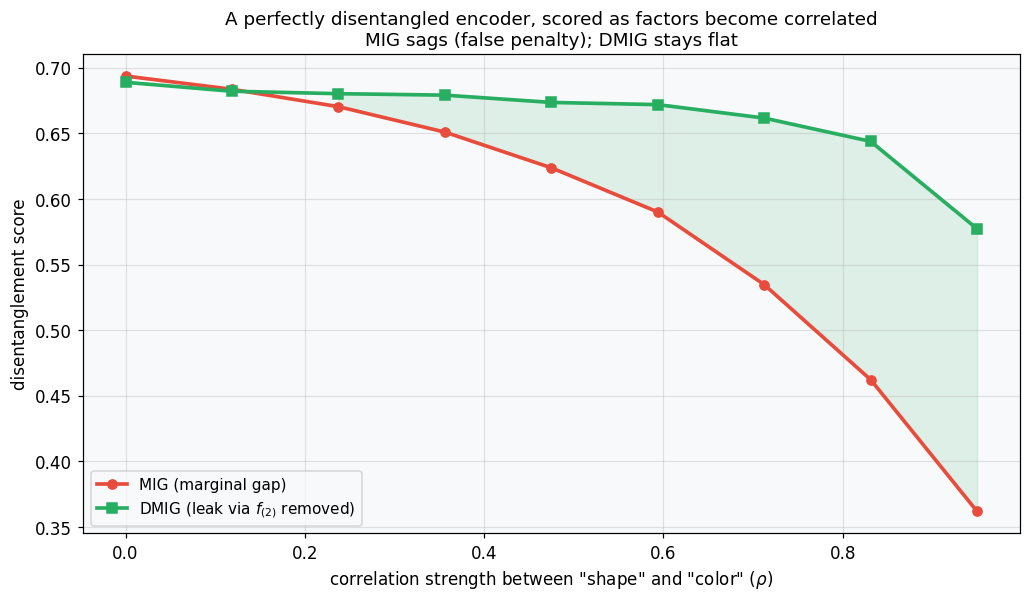

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.plot(rhos, mig_curve, 'o-', color='#e74c3c', lw=2.4, label='MIG (marginal gap)')
ax.plot(rhos, dmig_curve, 's-', color='#27ae60', lw=2.4,
        label=r'DMIG (leak via $f_{(2)}$ removed)')
ax.fill_between(rhos, mig_curve, dmig_curve, where=(dmig_curve > mig_curve),
                color='#27ae60', alpha=0.12)
ax.set_xlabel(r'correlation strength between "shape" and "color" ($\rho$)')
ax.set_ylabel('disentanglement score')
ax.set_title('A perfectly disentangled encoder, scored as factors become correlated\n'
             'MIG sags (false penalty); DMIG stays flat')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The encoder is *identical and perfectly disentangled* at every point on the
   x-axis — only the correlation between `shape` and `color` grows. Plain **MIG** (red) slides downward
   as the correlation increases, falsely reporting that the representation got worse. **DMIG** (green)
   stays nearly flat — only drooping at extreme correlation, where the histogram MI estimate itself
   degrades — correctly reporting that the encoder never changed.

2. **Why it looks this way:** As `shape` and `color` become correlated, the dimension owning `shape`
   inevitably shares mutual information with `color` too. MIG's gap (top-1 − top-2) shrinks for `color`
   because the second-best dimension now looks informative — but only *because* of the factor
   correlation, not because of any spillover in the encoder. DMIG replaces that second term with the
   **conditional** MI $I(z_{(2)}; f_j \mid f_{(2)})$, which subtracts the information the second
   dimension carries *only through* the correlated factor it owns — restoring the gap.

3. **Key takeaway:** A metric is only as trustworthy as its assumptions. MIG's hidden premise of
   independent factors makes it unreliable on realistic, correlated data — and **DMIG** is the targeted
   fix. This closes the loop on the research file's three families: information-based (MIG/DMIG),
   predictor-based (DCI), and intervention-based (FactorVAE) — each measuring disentanglement from a
   different angle, each with a characteristic blind spot.

---
## Summary

| Experiment | Metric family | Key insight |
|---|---|---|
| 1. MI matrix | (foundation) | Disentanglement has a visual signature: a sparse, one-winner-per-row-and-column mutual-information matrix |
| 2. MIG | Information | Scores "one factor, one dimension" as the normalized **gap** between the top-2 latent dimensions |
| 3. DCI | Predictor | Turns predictor importances into **Disentanglement** (per-dimension) and **Completeness** (per-factor) concentration |
| 4. DCI blind spot | Predictor | A powerful nonlinear predictor reports high **Informativeness** on an entangled latent — decodability ≠ disentanglement |
| 5. FactorVAE | Intervention | **Pin a factor**, and the dimension whose variance collapses reveals which axis encodes it — causal in spirit |
| 6. MIG vs DMIG | Information | MIG falsely penalizes a perfect encoder when factors correlate; **DMIG**'s conditional-MI gap repairs it |

### The big picture

Disentanglement is easy to define ("one slider, one factor") and surprisingly hard to *measure*.
The three families approach it from different directions — **information** (how much a dimension knows
about a factor), **prediction** (how concentrated a predictor's reliance is), and **intervention**
(how the latent responds when a factor is manipulated). Crucially, **no single metric is sufficient**:
MIG assumes independent factors (Exp 6), DCI is hostage to its predictor (Exp 4), and intervention
metrics need careful normalization (Exp 5). A trustworthy evaluation reports several, understands what
each one is blind to, and — for the manipulation goals of this project — leans toward the
intervention/causal metrics that most directly test "does pulling this slider change only the thing it
should?".